# AORC HUC-12 Rx24h validation using three spatial-weighting methods

## Target watershed

- **HUC-12:** `031401070103`
- **Name expected from WBD:** Bridge Creek–Perdido Bay
- **Event:** September 2020 intense-rainfall period
- **Objective:** determine whether the previously reported approximately **500.61 mm Rx24h** value is sensitive to the spatial aggregation method.

## Online data workflow

This notebook is adapted from the earlier `IntenseRainfall_And_Flooding_Analysis` notebook and uses the same online sources:

1. **HUC-12 boundary:** USGS Watershed Boundary Dataset ArcGIS REST service, 12-digit HU layer.
2. **AORC precipitation:** NOAA public AORC Version 1.1 annual Zarr store accessed anonymously through the S3 API.
3. **Variable:** `APCP_surface`, treated as one-hour accumulated precipitation in millimetres ending at each timestamp.

No local HUC shapefile, local AORC archive, or previously generated annual-metrics file is required.

## Three methods

1. **Center-cell area weighting** — reproduces the logic of the original notebook: a cell is included when its centre lies in the HUC-12 and is weighted by physical cell area.
2. **CIROH-style exact coverage-fraction weighting** — every intersecting cell is weighted by the fraction of that cell covered by the HUC-12.
3. **Coverage fraction × physical cell area** — every intersecting cell is weighted by its exact coverage fraction multiplied by the spherical AORC grid-cell area; this is the preferred hybrid.

The notebook first identifies the Method-1 rolling 24-hour maximum in the selected storm search period. It then forces all three methods to use the **same 24 hourly samples**, allowing a defensible sensitivity comparison.


## Cell 1 — Install required packages

Run this only when the environment does not already contain the packages. Restart the kernel after installation if Jupyter requests it.

In [1]:
# Uncomment and run if needed.
%pip install -q \
    "numpy>=1.26,<3" \
    "pandas>=2.2,<3" \
    "xarray>=2024.10,<2027" \
    "dask[array]>=2024.10,<2027" \
    "s3fs>=2024.10,<2027" \
    "zarr>=2.18,<3" \
    "numcodecs>=0.12,<0.16" \
    "geopandas>=1.0,<2" \
    "pyogrio>=0.9,<1" \
    "shapely>=2.0,<3" \
    "pyproj>=3.6,<4" \
    "pyarrow>=16,<23" \
    "matplotlib>=3.8,<4" \
    "requests>=2.32,<3"


Note: you may need to restart the kernel to use updated packages.


## Cell 2 — Imports, project folders, data sources and analysis settings

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import shutil
import warnings

from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable, Sequence

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import s3fs
import xarray as xr

from requests.adapters import HTTPAdapter
from shapely import make_valid
from shapely.geometry import Point, box
from urllib3.util.retry import Retry

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------
# Project folders
# ------------------------------------------------------------
PROJECT_DIR = Path.cwd() / "AORC_HUC12_Three_Method_Validation"
BOUNDARY_DIR = PROJECT_DIR / "01_boundaries"
DATA_DIR = PROJECT_DIR / "02_event_data"
TABLE_DIR = PROJECT_DIR / "03_tables"
FIGURE_DIR = PROJECT_DIR / "04_figures"
METADATA_DIR = PROJECT_DIR / "05_reproducibility"

for directory in [
    PROJECT_DIR,
    BOUNDARY_DIR,
    DATA_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    METADATA_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Online sources — same services used in the earlier notebook
# ------------------------------------------------------------
AORC_BUCKET = "noaa-nws-aorc-v1-1-1km"
AORC_VARIABLE = "APCP_surface"

WBD_LAYER_URL = (
    "https://hydro.nationalmap.gov/"
    "arcgis/rest/services/wbd/FeatureServer/6"
)
WBD_QUERY_URL = f"{WBD_LAYER_URL}/query"

CENSUS_STATE_LAYER_URL = (
    "https://tigerweb.geo.census.gov/"
    "arcgis/rest/services/TIGERweb/"
    "State_County/MapServer/2"
)
CENSUS_STATE_QUERY_URL = f"{CENSUS_STATE_LAYER_URL}/query"

# ------------------------------------------------------------
# Target and event settings
# ------------------------------------------------------------
TARGET_HUC12 = "031401070103"
EVENT_YEAR = 2020

# Search for the original center-cell Rx24h maximum during Sally.
SEARCH_START_UTC = "2020-09-14 00:00:00"
SEARCH_END_UTC = "2020-09-19 23:00:00"

# Set to a timestamp string to force a specific end time.
# Leave as None to identify the Method-1 peak automatically.
EVENT_END_OVERRIDE_UTC = None

ORIGINAL_REPORTED_RX24H_MM = 500.61
MIN_SPATIAL_COVERAGE = 0.95
BBOX_BUFFER_DEGREES = 0.05

# Hours shown before and after the recovered fixed event window.
DISPLAY_HOURS_BEFORE = 48
DISPLAY_HOURS_AFTER = 36

# Equal-area CRS used for exact physical overlap calculations.
AREA_CRS = "EPSG:5070"

# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------
TARGET_HUC_GPKG = BOUNDARY_DIR / f"wbd_huc12_{TARGET_HUC12}.gpkg"
ALABAMA_GPKG = BOUNDARY_DIR / "alabama_state_boundary.gpkg"
CELL_WEIGHTS_GPKG = DATA_DIR / f"aorc_cell_weights_{TARGET_HUC12}.gpkg"
EVENT_GRID_PARQUET = DATA_DIR / f"aorc_event_grid_{TARGET_HUC12}_{EVENT_YEAR}.parquet"

print(f"Project directory:\n{PROJECT_DIR}")
print(f"Target HUC-12: {TARGET_HUC12}")
print(f"Storm search period: {SEARCH_START_UTC} to {SEARCH_END_UTC} UTC")


Project directory:
D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation
Target HUC-12: 031401070103
Storm search period: 2020-09-14 00:00:00 to 2020-09-19 23:00:00 UTC


## Cell 3 — Download the target HUC-12 and Alabama boundary online

In [2]:
def safe_delete(path: Path) -> None:
    """Delete a file or directory when it exists."""
    if not path.exists():
        return
    if path.is_dir():
        shutil.rmtree(path)
    else:
        path.unlink()


def normalize_huc12(value: str | int) -> str:
    """Return a 12-character HUC code while preserving leading zeros."""
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(12)


def create_retry_session(
    total_retries: int = 6,
    backoff_factor: float = 2.0,
) -> requests.Session:
    """Create a requests session with retries for temporary server errors."""
    retry_strategy = Retry(
        total=total_retries,
        connect=total_retries,
        read=total_retries,
        status=total_retries,
        backoff_factor=backoff_factor,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET", "POST"]),
        raise_on_status=False,
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)
    session = requests.Session()
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    session.headers.update({
        "User-Agent": (
            "CRIMSON-AORC-HUC12-Three-Method-Validation/1.0 "
            "(University research)"
        )
    })
    return session


def request_arcgis_json(
    session: requests.Session,
    url: str,
    parameters: dict,
    timeout: int = 240,
) -> dict:
    """Submit an ArcGIS REST POST request and validate the JSON response."""
    response = session.post(url, data=parameters, timeout=timeout)
    response.raise_for_status()

    try:
        response_json = response.json()
    except ValueError as error:
        raise RuntimeError(
            "ArcGIS service did not return valid JSON.\n"
            f"Response preview:\n{response.text[:1000]}"
        ) from error

    if isinstance(response_json, dict) and "error" in response_json:
        raise RuntimeError(
            "ArcGIS service returned an error:\n"
            + json.dumps(response_json["error"], indent=2)
        )

    return response_json


def geojson_to_geodataframe(
    response_json: dict,
    crs: str = "EPSG:4326",
) -> gpd.GeoDataFrame:
    """Convert an ArcGIS GeoJSON response into a GeoDataFrame."""
    features = response_json.get("features", [])
    if not features:
        return gpd.GeoDataFrame(geometry=[], crs=crs)
    return gpd.GeoDataFrame.from_features(features, crs=crs)


def download_target_huc12(
    huc12_code: str,
    output_path: Path,
    overwrite: bool = False,
) -> gpd.GeoDataFrame:
    """Download one complete HUC-12 polygon from the USGS WBD REST layer."""
    huc12_code = normalize_huc12(huc12_code)

    if output_path.exists() and not overwrite:
        frame = gpd.read_file(output_path, layer="huc12")
        frame.columns = [str(column).lower() for column in frame.columns]
        frame["huc12"] = frame["huc12"].map(normalize_huc12)
        return frame.to_crs("EPSG:4326")

    session = create_retry_session()
    try:
        response_json = request_arcgis_json(
            session=session,
            url=WBD_QUERY_URL,
            parameters={
                "where": f"huc12 = '{huc12_code}'",
                "outFields": (
                    "objectid,huc12,name,areasqkm,states,"
                    "tohuc,hutype,noncontributingareasqkm"
                ),
                "returnGeometry": "true",
                "outSR": "4326",
                "returnZ": "false",
                "returnM": "false",
                "f": "geojson",
            },
            timeout=300,
        )
    finally:
        session.close()

    frame = geojson_to_geodataframe(response_json, crs="EPSG:4326")
    if frame.empty:
        raise RuntimeError(f"USGS WBD returned no polygon for HUC-12 {huc12_code}.")

    frame.columns = [str(column).lower() for column in frame.columns]
    frame = frame[frame.geometry.notna() & ~frame.geometry.is_empty].copy()
    frame["geometry"] = frame.geometry.apply(make_valid)
    frame["huc12"] = frame["huc12"].map(normalize_huc12)
    frame = frame[frame["huc12"] == huc12_code].copy()

    if frame.empty:
        raise RuntimeError("The returned WBD feature did not match the requested HUC code.")

    frame = frame.drop_duplicates(subset="huc12").reset_index(drop=True)
    safe_delete(output_path)
    frame.to_file(output_path, layer="huc12", driver="GPKG")
    return frame


def download_alabama_boundary(
    output_path: Path,
    overwrite: bool = False,
) -> gpd.GeoDataFrame:
    """Download Alabama's state boundary from Census TIGERweb."""
    if output_path.exists() and not overwrite:
        return gpd.read_file(output_path, layer="alabama").to_crs("EPSG:4326")

    session = create_retry_session()
    try:
        response_json = request_arcgis_json(
            session=session,
            url=CENSUS_STATE_QUERY_URL,
            parameters={
                "where": "STATE = '01'",
                "outFields": "OBJECTID,STATE,STUSAB,GEOID,NAME,BASENAME",
                "returnGeometry": "true",
                "outSR": "4326",
                "f": "geojson",
            },
            timeout=240,
        )
    finally:
        session.close()

    frame = geojson_to_geodataframe(response_json, crs="EPSG:4326")
    if frame.empty:
        raise RuntimeError("Census TIGERweb returned no Alabama boundary.")

    frame = frame[frame.geometry.notna() & ~frame.geometry.is_empty].copy()
    frame["geometry"] = frame.geometry.apply(make_valid)
    state_geometry = frame.geometry.union_all()

    output = gpd.GeoDataFrame(
        {
            "state_fips": ["01"],
            "state_abbreviation": ["AL"],
            "state_name": ["Alabama"],
        },
        geometry=[state_geometry],
        crs="EPSG:4326",
    )

    safe_delete(output_path)
    output.to_file(output_path, layer="alabama", driver="GPKG")
    return output


target_huc = download_target_huc12(
    TARGET_HUC12,
    TARGET_HUC_GPKG,
    overwrite=False,
)

alabama = download_alabama_boundary(
    ALABAMA_GPKG,
    overwrite=False,
)

target_name = str(target_huc.iloc[0].get("name", TARGET_HUC12))
target_states = str(target_huc.iloc[0].get("states", ""))
target_wbd_area_km2 = float(target_huc.iloc[0].get("areasqkm", np.nan))

print(f"Downloaded HUC-12: {TARGET_HUC12}")
print(f"Name: {target_name}")
print(f"States: {target_states}")
print(f"WBD area: {target_wbd_area_km2:.2f} km²")

display(target_huc[["huc12", "name", "states", "areasqkm"]])


Downloaded HUC-12: 031401070103
Name: Bridge Creek-Perdido Bay
States: AL,FL
WBD area: 74.11 km²


,huc12,name,states,areasqkm
0,031401070103,Bridge Creek-Perdido Bay,"AL,FL",74.11


## Cell 4 — Context map of the online WBD polygon

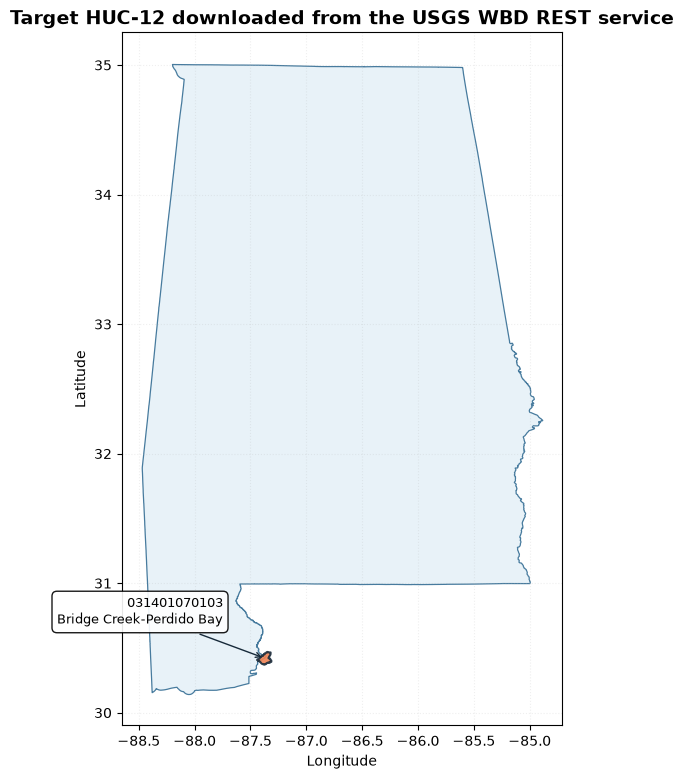

Saved: D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\04_figures\fig00_target_huc12_context.png


In [3]:
figure, axis = plt.subplots(figsize=(8, 9))

alabama.plot(
    ax=axis,
    color="#e8f2f8",
    edgecolor="#477b9e",
    linewidth=0.9,
)

target_huc.plot(
    ax=axis,
    color="#ef8354",
    edgecolor="#172a3a",
    linewidth=1.5,
    alpha=0.9,
)

centroid = target_huc.to_crs(AREA_CRS).centroid.to_crs("EPSG:4326").iloc[0]
axis.annotate(
    f"{TARGET_HUC12}\n{target_name}",
    xy=(centroid.x, centroid.y),
    xytext=(-30, 25),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "alpha": 0.9},
    arrowprops={"arrowstyle": "->", "color": "#172a3a"},
)

axis.set_title(
    "Target HUC-12 downloaded from the USGS WBD REST service",
    fontsize=14,
    fontweight="bold",
)
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(alpha=0.2, linestyle=":")

context_path = FIGURE_DIR / "fig00_target_huc12_context.png"
figure.savefig(context_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {context_path}")


## Cell 5 — Connect anonymously to NOAA AORC and load the local storm window

In [4]:
aorc_s3 = s3fs.S3FileSystem(anon=True)


def open_aorc_year(year: int) -> xr.Dataset:
    """Lazily open one annual AORC Zarr store from NOAA's public S3 bucket."""
    store_path = f"{AORC_BUCKET}/{int(year)}.zarr"
    mapper = aorc_s3.get_mapper(store_path)

    try:
        return xr.open_zarr(
            mapper,
            consolidated=True,
            chunks={},
            decode_cf=True,
        )
    except Exception:
        # Fallback in case consolidated metadata is temporarily unavailable.
        return xr.open_zarr(
            mapper,
            consolidated=False,
            chunks={},
            decode_cf=True,
        )


def find_coordinate_name(
    available_names: Iterable[str],
    candidate_names: Sequence[str],
    description: str,
) -> str:
    """Locate a coordinate or dimension using alternative names."""
    available_names = list(available_names)
    lowercase_lookup = {name.lower(): name for name in available_names}

    for candidate in candidate_names:
        if candidate.lower() in lowercase_lookup:
            return lowercase_lookup[candidate.lower()]

    raise KeyError(
        f"Could not find {description}. Available names: {available_names}"
    )


def get_huc_bounds(
    huc_frame: gpd.GeoDataFrame,
    buffer_degrees: float = BBOX_BUFFER_DEGREES,
) -> tuple[float, float, float, float]:
    """Return a buffered bounding box around the complete HUC polygon."""
    minx, miny, maxx, maxy = huc_frame.to_crs("EPSG:4326").total_bounds
    return (
        minx - buffer_degrees,
        miny - buffer_degrees,
        maxx + buffer_degrees,
        maxy + buffer_degrees,
    )


def get_aorc_precipitation(
    year: int,
    bounds: tuple[float, float, float, float],
    start: str,
    end: str,
) -> tuple[xr.DataArray, xr.Dataset]:
    """Open and subset AORC APCP_surface by space and time."""
    source_dataset = open_aorc_year(year)

    if AORC_VARIABLE not in source_dataset.data_vars:
        raise KeyError(
            f"{AORC_VARIABLE!r} was not found. "
            f"Variables: {list(source_dataset.data_vars)}"
        )

    precipitation = source_dataset[AORC_VARIABLE]
    available_names = list(precipitation.dims) + list(precipitation.coords)

    time_name = find_coordinate_name(
        available_names,
        ["time", "valid_time"],
        "time coordinate",
    )
    latitude_name = find_coordinate_name(
        available_names,
        ["latitude", "lat", "y"],
        "latitude coordinate",
    )
    longitude_name = find_coordinate_name(
        available_names,
        ["longitude", "lon", "x"],
        "longitude coordinate",
    )

    rename_dictionary = {}
    if time_name != "time":
        rename_dictionary[time_name] = "time"
    if latitude_name != "lat":
        rename_dictionary[latitude_name] = "lat"
    if longitude_name != "lon":
        rename_dictionary[longitude_name] = "lon"

    precipitation = precipitation.rename(rename_dictionary)

    if float(precipitation["lon"].max()) > 180:
        precipitation = precipitation.assign_coords(
            lon=((precipitation["lon"] + 180) % 360) - 180
        )

    precipitation = precipitation.sortby("lon", ascending=True)
    precipitation = precipitation.sortby("lat", ascending=False)

    minx, miny, maxx, maxy = bounds
    precipitation = precipitation.sel(
        lon=slice(minx, maxx),
        lat=slice(maxy, miny),
        time=slice(start, end),
    )

    time_index = pd.DatetimeIndex(precipitation["time"].values)
    if time_index.has_duplicates:
        keep_positions = np.flatnonzero(~time_index.duplicated(keep="first"))
        precipitation = precipitation.isel(time=keep_positions)

    precipitation = precipitation.where(precipitation >= 0).astype("float32")
    precipitation.name = "aorc_precip_mm"
    precipitation.attrs.update({
        "long_name": "AORC one-hour accumulated surface precipitation",
        "units": "mm",
        "source_variable": AORC_VARIABLE,
        "timestamp_interpretation": "One-hour accumulation ending at timestamp",
    })

    if precipitation.sizes.get("lat", 0) == 0:
        raise RuntimeError("The AORC latitude subset is empty.")
    if precipitation.sizes.get("lon", 0) == 0:
        raise RuntimeError("The AORC longitude subset is empty.")
    if precipitation.sizes.get("time", 0) == 0:
        raise RuntimeError("The AORC time subset is empty.")

    return precipitation, source_dataset


search_start = pd.Timestamp(SEARCH_START_UTC)
search_end = pd.Timestamp(SEARCH_END_UTC)

# Load 23 earlier hours so the first search-hour rolling total can be complete.
load_start = search_start - pd.Timedelta(hours=23)
load_end = search_end

huc_bounds = get_huc_bounds(target_huc)

print("Opening the NOAA AORC annual Zarr store...")
precipitation, aorc_source_dataset = get_aorc_precipitation(
    year=EVENT_YEAR,
    bounds=huc_bounds,
    start=str(load_start),
    end=str(load_end),
)

# This local subset is small enough to load into memory.
precipitation = precipitation.load()

print("AORC local subset loaded.")
print(f"Shape (time, lat, lon): {precipitation.shape}")
print(f"First timestamp: {precipitation.time.values[0]}")
print(f"Last timestamp:  {precipitation.time.values[-1]}")
print(f"Latitude cells: {precipitation.sizes['lat']}")
print(f"Longitude cells: {precipitation.sizes['lon']}")
print(f"Variable units: {precipitation.attrs.get('units')}")


C:\Users\ioolajide\AppData\Local\Temp\2\ipykernel_13040\2195442360.py:145: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  load_start = search_start - pd.Timedelta(hours=23)


Opening the NOAA AORC annual Zarr store...
AORC local subset loaded.
Shape (time, lat, lon): (167, 24, 28)
First timestamp: 2020-09-13T01:00:00.000000000
Last timestamp:  2020-09-19T23:00:00.000000000
Latitude cells: 24
Longitude cells: 28
Variable units: mm


## Cell 6 — Build the local AORC grid and calculate the three spatial weights

In [5]:
def cell_edges_from_centres(values: np.ndarray) -> np.ndarray:
    """Infer cell edges from regularly spaced cell-centre coordinates."""
    values = np.asarray(values, dtype="float64")
    if len(values) < 2:
        raise ValueError("At least two coordinate values are required.")

    # Work in ascending order when calculating edges.
    ascending = np.all(np.diff(values) > 0)
    working = values if ascending else values[::-1]
    differences = np.diff(working)

    edges = np.concatenate([
        [working[0] - differences[0] / 2],
        working[:-1] + differences / 2,
        [working[-1] + differences[-1] / 2],
    ])

    return edges if ascending else edges[::-1]


def spherical_grid_cell_area_m2(
    south_degrees: float,
    north_degrees: float,
    west_degrees: float,
    east_degrees: float,
) -> float:
    """
    Calculate geographic grid-cell area using the same spherical approach
    as the original HUC-12 notebook.
    """
    earth_radius_metres = 6_371_008.8
    south_radians = math.radians(south_degrees)
    north_radians = math.radians(north_degrees)
    longitude_width_radians = math.radians(abs(east_degrees - west_degrees))

    return (
        earth_radius_metres**2
        * longitude_width_radians
        * abs(math.sin(north_radians) - math.sin(south_radians))
    )


def build_aorc_cell_weights(
    precipitation_template: xr.DataArray,
    huc_frame: gpd.GeoDataFrame,
    area_crs: str = AREA_CRS,
) -> gpd.GeoDataFrame:
    """
    Create local grid-cell polygons and the three requested weight definitions.

    Method 1: centre in HUC × spherical physical cell area.
    Method 2: exact HUC coverage fraction of each cell.
    Method 3: exact coverage fraction × spherical physical cell area.
    """
    latitude_values = np.asarray(
        precipitation_template["lat"].values,
        dtype="float64",
    )
    longitude_values = np.asarray(
        precipitation_template["lon"].values,
        dtype="float64",
    )

    latitude_edges = cell_edges_from_centres(latitude_values)
    longitude_edges = cell_edges_from_centres(longitude_values)

    huc_geometry = huc_frame.to_crs("EPSG:4326").geometry.union_all()
    records = []

    for row_index, latitude in enumerate(latitude_values):
        lat_a = latitude_edges[row_index]
        lat_b = latitude_edges[row_index + 1]
        south = min(lat_a, lat_b)
        north = max(lat_a, lat_b)

        for column_index, longitude in enumerate(longitude_values):
            lon_a = longitude_edges[column_index]
            lon_b = longitude_edges[column_index + 1]
            west = min(lon_a, lon_b)
            east = max(lon_a, lon_b)

            cell_geometry = box(west, south, east, north)
            centre_point = Point(float(longitude), float(latitude))
            spherical_area = spherical_grid_cell_area_m2(
                south_degrees=south,
                north_degrees=north,
                west_degrees=west,
                east_degrees=east,
            )

            records.append({
                "row": int(row_index),
                "col": int(column_index),
                "latitude": float(latitude),
                "longitude": float(longitude),
                "center_in_huc": bool(huc_geometry.covers(centre_point)),
                "cell_area_spherical_m2": float(spherical_area),
                "geometry": cell_geometry,
            })

    cells = gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs="EPSG:4326",
    )

    # Exact cell/HUC overlap is calculated in a CONUS equal-area CRS.
    projected_cells = cells.to_crs(area_crs)
    projected_huc_geometry = huc_frame.to_crs(area_crs).geometry.union_all()

    projected_cells["cell_area_projected_m2"] = (
        projected_cells.geometry.area.astype("float64")
    )
    intersection_geometry = projected_cells.geometry.intersection(
        projected_huc_geometry
    )
    projected_cells["geometric_overlap_area_m2"] = (
        intersection_geometry.area.astype("float64")
    )
    projected_cells["coverage_fraction"] = (
        projected_cells["geometric_overlap_area_m2"]
        / projected_cells["cell_area_projected_m2"].replace(0, np.nan)
    ).clip(lower=0, upper=1).fillna(0)

    # Three requested weight definitions.
    projected_cells["weight_center_area"] = np.where(
        projected_cells["center_in_huc"],
        projected_cells["cell_area_spherical_m2"],
        0.0,
    )
    projected_cells["weight_coverage_fraction"] = (
        projected_cells["coverage_fraction"]
    )
    projected_cells["weight_coverage_area"] = (
        projected_cells["coverage_fraction"]
        * projected_cells["cell_area_spherical_m2"]
    )

    # Normalized static contribution percentages for maps.
    for weight_column in [
        "weight_center_area",
        "weight_coverage_fraction",
        "weight_coverage_area",
    ]:
        total_weight = projected_cells[weight_column].sum()
        output_column = f"{weight_column}_pct"
        projected_cells[output_column] = np.where(
            total_weight > 0,
            100.0 * projected_cells[weight_column] / total_weight,
            0.0,
        )

    # Return in geographic coordinates while retaining physical-area attributes.
    return projected_cells.to_crs("EPSG:4326")


cell_weights = build_aorc_cell_weights(
    precipitation_template=precipitation,
    huc_frame=target_huc,
)

represented_center_area_km2 = (
    cell_weights["weight_center_area"].sum() / 1e6
)
coverage_area_km2 = (
    cell_weights["weight_coverage_area"].sum() / 1e6
)
geometric_overlap_area_km2 = (
    cell_weights["geometric_overlap_area_m2"].sum() / 1e6
)

print("Grid-cell representation summary")
print(f"Local grid cells: {len(cell_weights):,}")
print(f"Cell centres inside HUC: {int(cell_weights['center_in_huc'].sum()):,}")
print(f"Cells intersecting HUC: {int((cell_weights['coverage_fraction'] > 0).sum()):,}")
print(f"Center-cell represented area: {represented_center_area_km2:.3f} km²")
print(f"Coverage × spherical cell area: {coverage_area_km2:.3f} km²")
print(f"Equal-area geometric overlap: {geometric_overlap_area_km2:.3f} km²")
print(f"WBD reported area: {target_wbd_area_km2:.3f} km²")
print(
    "Center-cell area difference from coverage-area representation: "
    f"{100 * (represented_center_area_km2 - coverage_area_km2) / coverage_area_km2:+.2f}%"
)

safe_delete(CELL_WEIGHTS_GPKG)
cell_weights.to_file(
    CELL_WEIGHTS_GPKG,
    layer="aorc_cells",
    driver="GPKG",
)
print(f"Saved cell weights: {CELL_WEIGHTS_GPKG}")


Grid-cell representation summary
Local grid cells: 672
Cell centres inside HUC: 102
Cells intersecting HUC: 130
Center-cell represented area: 75.518 km²
Coverage × spherical cell area: 74.183 km²
Equal-area geometric overlap: 74.106 km²
WBD reported area: 74.110 km²
Center-cell area difference from coverage-area representation: +1.80%
Saved cell weights: D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\02_event_data\aorc_cell_weights_031401070103.gpkg


## Cell 7 — Calculate hourly HUC averages for the three methods

In [6]:
METHODS = {
    "center_area": {
        "label": "Method 1: Center-cell area",
        "short_label": "Center-cell area",
        "weight_column": "weight_center_area",
        "color": "#2166ac",
    },
    "coverage_fraction": {
        "label": "Method 2: CIROH-style coverage fraction",
        "short_label": "Coverage fraction",
        "weight_column": "weight_coverage_fraction",
        "color": "#d6604d",
    },
    "coverage_area": {
        "label": "Method 3: Coverage fraction × physical cell area",
        "short_label": "Coverage × area",
        "weight_column": "weight_coverage_area",
        "color": "#1b9e77",
    },
}


def weights_to_array(
    cells: gpd.GeoDataFrame,
    weight_column: str,
    latitude_count: int,
    longitude_count: int,
) -> np.ndarray:
    """Place a cell-weight column into an array aligned with the AORC grid."""
    output = np.zeros((latitude_count, longitude_count), dtype="float64")
    for row in cells.itertuples(index=False):
        output[int(row.row), int(row.col)] = float(getattr(row, weight_column))
    return output


def calculate_weighted_hourly_series(
    precipitation_array: xr.DataArray,
    cells: gpd.GeoDataFrame,
    weight_column: str,
    minimum_coverage: float = MIN_SPATIAL_COVERAGE,
) -> tuple[pd.Series, pd.Series]:
    """Calculate an hourly weighted HUC mean and valid-weight coverage."""
    values = np.asarray(precipitation_array.values, dtype="float64")
    time_index = pd.DatetimeIndex(precipitation_array["time"].values)

    number_of_times, number_of_latitudes, number_of_longitudes = values.shape
    weight_grid = weights_to_array(
        cells,
        weight_column,
        number_of_latitudes,
        number_of_longitudes,
    )

    flat_values = values.reshape(number_of_times, -1)
    flat_weights = weight_grid.reshape(-1)
    total_static_weight = flat_weights.sum()

    if total_static_weight <= 0:
        raise ValueError(f"Weight column {weight_column!r} has zero total weight.")

    valid = np.isfinite(flat_values)
    observed_weight = np.sum(valid * flat_weights[None, :], axis=1)
    numerator = np.nansum(flat_values * flat_weights[None, :], axis=1)

    basin_mean = np.full(number_of_times, np.nan, dtype="float64")
    valid_denominator = observed_weight > 0
    basin_mean[valid_denominator] = (
        numerator[valid_denominator] / observed_weight[valid_denominator]
    )

    coverage_fraction = observed_weight / total_static_weight
    basin_mean[coverage_fraction < minimum_coverage] = np.nan

    return (
        pd.Series(basin_mean, index=time_index, name=weight_column),
        pd.Series(coverage_fraction, index=time_index, name=f"{weight_column}_coverage"),
    )


hourly_series = {}
coverage_series = {}

for method_key, method_info in METHODS.items():
    series, coverage = calculate_weighted_hourly_series(
        precipitation_array=precipitation,
        cells=cell_weights,
        weight_column=method_info["weight_column"],
    )
    hourly_series[method_key] = series
    coverage_series[method_key] = coverage

hourly_df = pd.DataFrame(hourly_series)
coverage_df = pd.DataFrame(coverage_series)
rolling24_df = hourly_df.rolling(window=24, min_periods=24).sum()

print("Hourly basin-average series created.")
print(hourly_df.describe())

minimum_coverage_table = coverage_df.min().rename("minimum_coverage").to_frame()
minimum_coverage_table["hours_below_95pct"] = (coverage_df < MIN_SPATIAL_COVERAGE).sum()
display(minimum_coverage_table)


Hourly basin-average series created.
       center_area  coverage_fraction  coverage_area
count   167.000000         167.000000     167.000000
mean      3.335823           3.330962       3.330974
std       9.781533           9.767348       9.767381
min       0.000000           0.000000       0.000000
25%       0.000000           0.000000       0.000000
50%       0.000000           0.000000       0.000000
75%       0.400979           0.398090       0.398089
max      74.598217          74.560649      74.560792


,minimum_coverage,hours_below_95pct
center_area,1.0,0
coverage_fraction,1.0,0
coverage_area,1.0,0


## Cell 8 — Recover the original Method-1 event window and force all methods to use the same 24 hours

In [7]:
def pct_difference(value: float, reference: float) -> float:
    if pd.isna(value) or pd.isna(reference) or reference == 0:
        return np.nan
    return 100.0 * (value - reference) / reference


search_roll24 = rolling24_df.loc[search_start:search_end]

if search_roll24["center_area"].dropna().empty:
    raise RuntimeError("No complete Method-1 rolling 24-hour windows were found.")

if EVENT_END_OVERRIDE_UTC is None:
    event_end = pd.Timestamp(search_roll24["center_area"].idxmax())
else:
    event_end = pd.Timestamp(EVENT_END_OVERRIDE_UTC)

# 24 hourly AORC samples ending at event_end: event_end-23 h through event_end.
event_first_sample = event_end - pd.Timedelta(hours=23)
# APCP_surface at each timestamp covers the preceding hour.
physical_period_start = event_end - pd.Timedelta(hours=24)

fixed_window_hourly = hourly_df.loc[event_first_sample:event_end].copy()
if len(fixed_window_hourly) != 24:
    raise RuntimeError(
        "The fixed comparison window does not contain exactly 24 hourly samples. "
        f"Found {len(fixed_window_hourly)}."
    )

fixed_totals = fixed_window_hourly.sum(axis=0, min_count=24)

summary_rows = []
for method_key, method_info in METHODS.items():
    local_roll = search_roll24[method_key].dropna()
    local_peak_end = local_roll.idxmax() if not local_roll.empty else pd.NaT
    local_peak_value = local_roll.max() if not local_roll.empty else np.nan

    summary_rows.append({
        "method_key": method_key,
        "method": method_info["label"],
        "fixed_window_rx24h_mm": float(fixed_totals[method_key]),
        "fixed_window_rx24h_inches": float(fixed_totals[method_key] / 25.4),
        "fixed_first_sample_utc": event_first_sample,
        "fixed_end_timestamp_utc": event_end,
        "physical_period_start_utc": physical_period_start,
        "method_specific_peak_mm_in_search_period": float(local_peak_value),
        "method_specific_peak_end_utc": local_peak_end,
    })

summary_df = pd.DataFrame(summary_rows)
center_total = float(summary_df.loc[
    summary_df["method_key"] == "center_area",
    "fixed_window_rx24h_mm",
].iloc[0])
hybrid_total = float(summary_df.loc[
    summary_df["method_key"] == "coverage_area",
    "fixed_window_rx24h_mm",
].iloc[0])

summary_df["pct_difference_vs_center"] = summary_df["fixed_window_rx24h_mm"].apply(
    lambda value: pct_difference(value, center_total)
)
summary_df["pct_difference_vs_hybrid"] = summary_df["fixed_window_rx24h_mm"].apply(
    lambda value: pct_difference(value, hybrid_total)
)
summary_df["pct_difference_vs_original_500_61"] = summary_df["fixed_window_rx24h_mm"].apply(
    lambda value: pct_difference(value, ORIGINAL_REPORTED_RX24H_MM)
)

method_range_mm = summary_df["fixed_window_rx24h_mm"].max() - summary_df["fixed_window_rx24h_mm"].min()
relative_spread_pct = 100.0 * method_range_mm / hybrid_total

if relative_spread_pct < 5:
    sensitivity_class = "Low sensitivity"
elif relative_spread_pct < 10:
    sensitivity_class = "Moderate sensitivity"
else:
    sensitivity_class = "High sensitivity"

print("Exact fixed comparison window")
print(f"First included AORC timestamp: {event_first_sample} UTC")
print(f"Last included AORC timestamp:  {event_end} UTC")
print(f"Physical accumulation period: {physical_period_start} to {event_end} UTC")
print(f"Method range: {method_range_mm:.2f} mm")
print(f"Relative spread vs hybrid: {relative_spread_pct:.2f}%")
print(f"Sensitivity classification: {sensitivity_class}")

display(summary_df)


Exact fixed comparison window
First included AORC timestamp: 2020-09-15 12:00:00 UTC
Last included AORC timestamp:  2020-09-16 11:00:00 UTC
Physical accumulation period: 2020-09-15 11:00:00 to 2020-09-16 11:00:00 UTC
Method range: 0.68 mm
Relative spread vs hybrid: 0.14%
Sensitivity classification: Low sensitivity


C:\Users\ioolajide\AppData\Local\Temp\2\ipykernel_13040\3318378247.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  event_first_sample = event_end - pd.Timedelta(hours=23)
C:\Users\ioolajide\AppData\Local\Temp\2\ipykernel_13040\3318378247.py:20: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  physical_period_start = event_end - pd.Timedelta(hours=24)


,method_key,method,fixed_window_rx24h_mm,fixed_window_rx24h_inches,fixed_first_sample_utc,fixed_end_timestamp_utc,physical_period_start_utc,method_specific_peak_mm_in_search_period,method_specific_peak_end_utc,pct_difference_vs_center,pct_difference_vs_hybrid,pct_difference_vs_original_500_61
0,center_area,Method 1: Center-cell area,500.612786,19.709165,2020-09-15 12:00:00,2020-09-16 11:00:00,2020-09-15 11:00:00,500.612786,2020-09-16 11:00:00,0.000000,0.135848,0.000556
1,coverage_fraction,Method 2: CIROH-style coverage fraction,499.930771,19.682314,2020-09-15 12:00:00,2020-09-16 11:00:00,2020-09-15 11:00:00,499.930771,2020-09-16 11:00:00,-0.136236,-0.000574,-0.135680
2,coverage_area,Method 3: Coverage fraction × physical cell area,499.933638,19.682427,2020-09-15 12:00:00,2020-09-16 11:00:00,2020-09-15 11:00:00,499.933638,2020-09-16 11:00:00,-0.135663,0.000000,-0.135108


## Cell 9 — Calculate each cell’s exact contribution to the fixed 24-hour HUC total

In [8]:
def calculate_event_cell_contributions(
    precipitation_array: xr.DataArray,
    cells: gpd.GeoDataFrame,
    weight_column: str,
    first_sample: pd.Timestamp,
    last_sample: pd.Timestamp,
) -> np.ndarray:
    """
    Calculate each grid cell's contribution to the final HUC total.

    The denominator is recalculated separately at every hour using only valid
    cells, matching the hourly weighted-mean computation. Cell contributions
    therefore sum exactly to the fixed-window basin total.
    """
    event_array = precipitation_array.sel(
        time=slice(first_sample, last_sample)
    )
    values = np.asarray(event_array.values, dtype="float64")

    if values.shape[0] != 24:
        raise RuntimeError(
            f"Expected 24 event hours but found {values.shape[0]}."
        )

    number_of_times, number_of_latitudes, number_of_longitudes = values.shape
    weight_grid = weights_to_array(
        cells,
        weight_column,
        number_of_latitudes,
        number_of_longitudes,
    )

    flat_values = values.reshape(number_of_times, -1)
    flat_weights = weight_grid.reshape(-1)
    valid = np.isfinite(flat_values)
    observed_weight = np.sum(valid * flat_weights[None, :], axis=1)

    contributions = np.zeros_like(flat_values, dtype="float64")
    for time_index in range(number_of_times):
        if observed_weight[time_index] <= 0:
            contributions[time_index, :] = np.nan
            continue

        contributions[time_index, :] = np.where(
            valid[time_index, :],
            flat_values[time_index, :]
            * flat_weights
            / observed_weight[time_index],
            0.0,
        )

    return np.nansum(contributions, axis=0)


for method_key, method_info in METHODS.items():
    cell_weights[f"event_contribution_{method_key}_mm"] = (
        calculate_event_cell_contributions(
            precipitation_array=precipitation,
            cells=cell_weights,
            weight_column=method_info["weight_column"],
            first_sample=event_first_sample,
            last_sample=event_end,
        )
    )

# Verify that mapped cell contributions sum to the tabulated HUC values.
validation_rows = []
for method_key in METHODS:
    mapped_sum = cell_weights[f"event_contribution_{method_key}_mm"].sum()
    tabulated_total = float(fixed_totals[method_key])
    validation_rows.append({
        "method_key": method_key,
        "sum_of_cell_contributions_mm": mapped_sum,
        "tabulated_fixed_total_mm": tabulated_total,
        "absolute_difference_mm": mapped_sum - tabulated_total,
    })

contribution_validation = pd.DataFrame(validation_rows)
display(contribution_validation)


,method_key,sum_of_cell_contributions_mm,tabulated_fixed_total_mm,absolute_difference_mm
0,center_area,500.612786,500.612786,0.000000e+00
1,coverage_fraction,499.930771,499.930771,-5.684342e-14
2,coverage_area,499.933638,499.933638,0.000000e+00


## Cell 10 — Figure 1: three-panel spatial-weight comparison

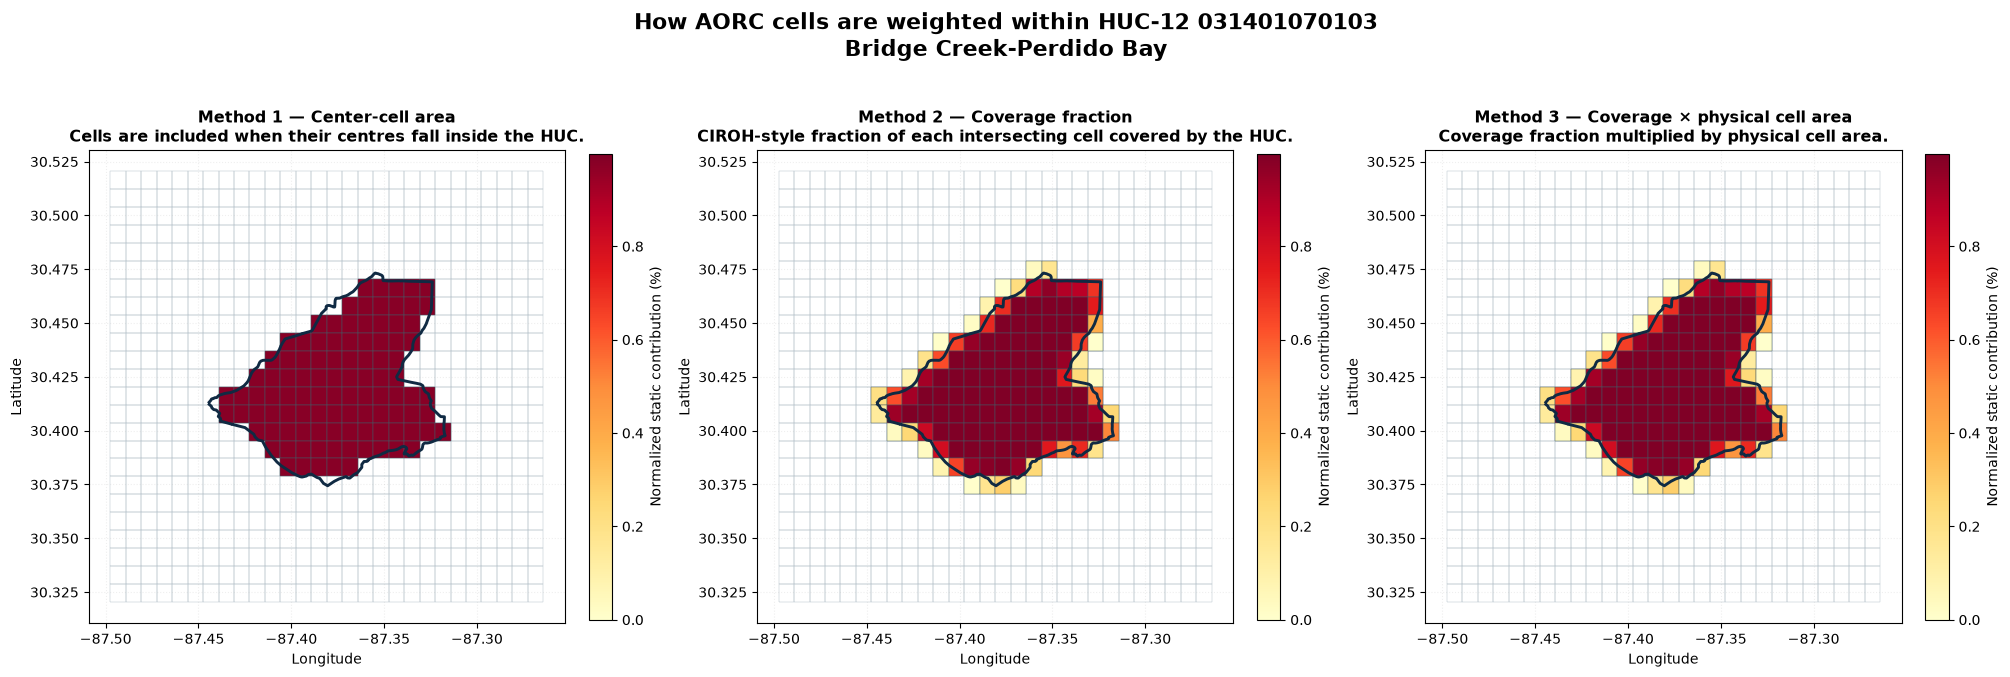

Saved: D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\04_figures\fig01_three_method_spatial_weights.png


In [9]:
weight_map_specs = [
    (
        "weight_center_area_pct",
        "Method 1 — Center-cell area",
        "Cells are included when their centres fall inside the HUC.",
    ),
    (
        "weight_coverage_fraction_pct",
        "Method 2 — Coverage fraction",
        "CIROH-style fraction of each intersecting cell covered by the HUC.",
    ),
    (
        "weight_coverage_area_pct",
        "Method 3 — Coverage × physical cell area",
        "Coverage fraction multiplied by physical cell area.",
    ),
]

common_weight_max = max(
    float(cell_weights[column].max())
    for column, _, _ in weight_map_specs
)

figure, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

for axis, (column, title, subtitle) in zip(axes, weight_map_specs):
    cell_weights.boundary.plot(
        ax=axis,
        color="#b8c4cc",
        linewidth=0.35,
        zorder=1,
    )

    active_cells = cell_weights[cell_weights[column] > 0].copy()
    active_cells.plot(
        ax=axis,
        column=column,
        cmap="YlOrRd",
        vmin=0,
        vmax=common_weight_max,
        edgecolor="#455a64",
        linewidth=0.35,
        legend=True,
        legend_kwds={
            "label": "Normalized static contribution (%)",
            "shrink": 0.74,
        },
        zorder=2,
    )

    target_huc.boundary.plot(
        ax=axis,
        color="#102a43",
        linewidth=2.1,
        zorder=3,
    )

    axis.set_title(f"{title}\n{subtitle}", fontsize=11.5, fontweight="bold")
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.grid(alpha=0.2, linestyle=":")

figure.suptitle(
    f"How AORC cells are weighted within HUC-12 {TARGET_HUC12}\n{target_name}",
    fontsize=16,
    fontweight="bold",
)

figure_path = FIGURE_DIR / "fig01_three_method_spatial_weights.png"
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")


## Cell 11 — Figure 2: three-panel cell contributions to the same 24-hour total

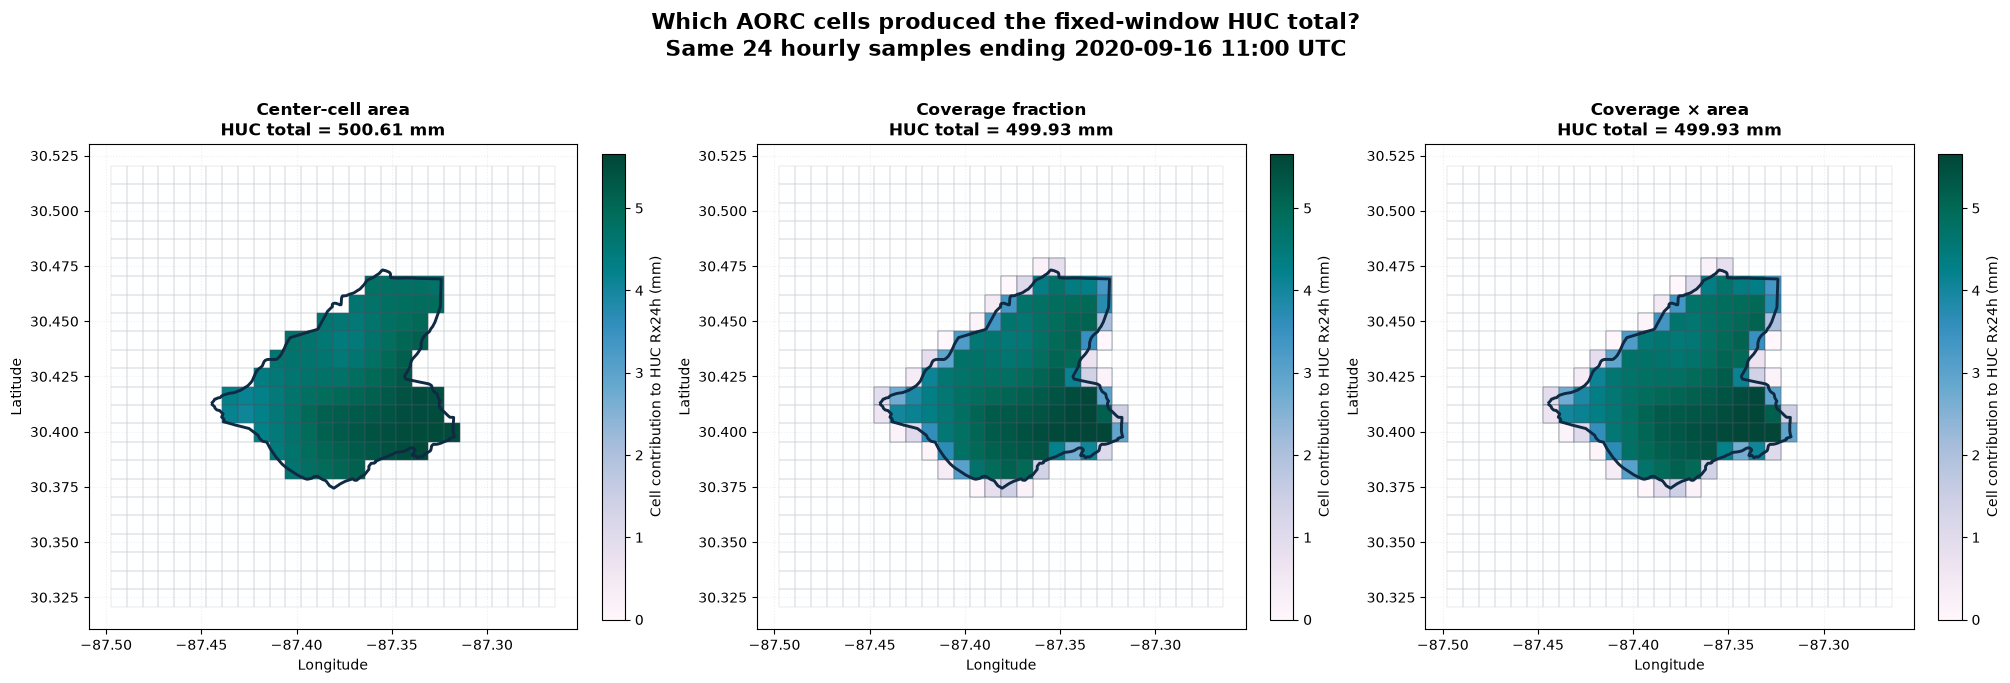

Saved: D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\04_figures\fig02_three_method_event_cell_contributions.png


In [10]:
contribution_columns = [
    "event_contribution_center_area_mm",
    "event_contribution_coverage_fraction_mm",
    "event_contribution_coverage_area_mm",
]

common_contribution_max = max(
    float(cell_weights[column].max())
    for column in contribution_columns
)

figure, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

for axis, (method_key, method_info), contribution_column in zip(
    axes,
    METHODS.items(),
    contribution_columns,
):
    cell_weights.boundary.plot(
        ax=axis,
        color="#c5cdd3",
        linewidth=0.3,
        zorder=1,
    )

    active_cells = cell_weights[cell_weights[contribution_column] > 0].copy()
    active_cells.plot(
        ax=axis,
        column=contribution_column,
        cmap="PuBuGn",
        vmin=0,
        vmax=common_contribution_max,
        edgecolor="#425563",
        linewidth=0.35,
        legend=True,
        legend_kwds={
            "label": "Cell contribution to HUC Rx24h (mm)",
            "shrink": 0.74,
        },
        zorder=2,
    )

    target_huc.boundary.plot(
        ax=axis,
        color="#102a43",
        linewidth=2.1,
        zorder=3,
    )

    method_total = float(fixed_totals[method_key])
    axis.set_title(
        f"{method_info['short_label']}\nHUC total = {method_total:.2f} mm",
        fontsize=12,
        fontweight="bold",
    )
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.grid(alpha=0.2, linestyle=":")

figure.suptitle(
    "Which AORC cells produced the fixed-window HUC total?\n"
    f"Same 24 hourly samples ending {event_end:%Y-%m-%d %H:%M} UTC",
    fontsize=16,
    fontweight="bold",
)

figure_path = FIGURE_DIR / "fig02_three_method_event_cell_contributions.png"
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")


## Cell 12 — Figure 3: three-panel event time-series and Rx24h comparison

C:\Users\ioolajide\AppData\Local\Temp\2\ipykernel_13040\1139353195.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  display_start = event_first_sample - pd.Timedelta(hours=DISPLAY_HOURS_BEFORE)
C:\Users\ioolajide\AppData\Local\Temp\2\ipykernel_13040\1139353195.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  display_end = event_end + pd.Timedelta(hours=DISPLAY_HOURS_AFTER)


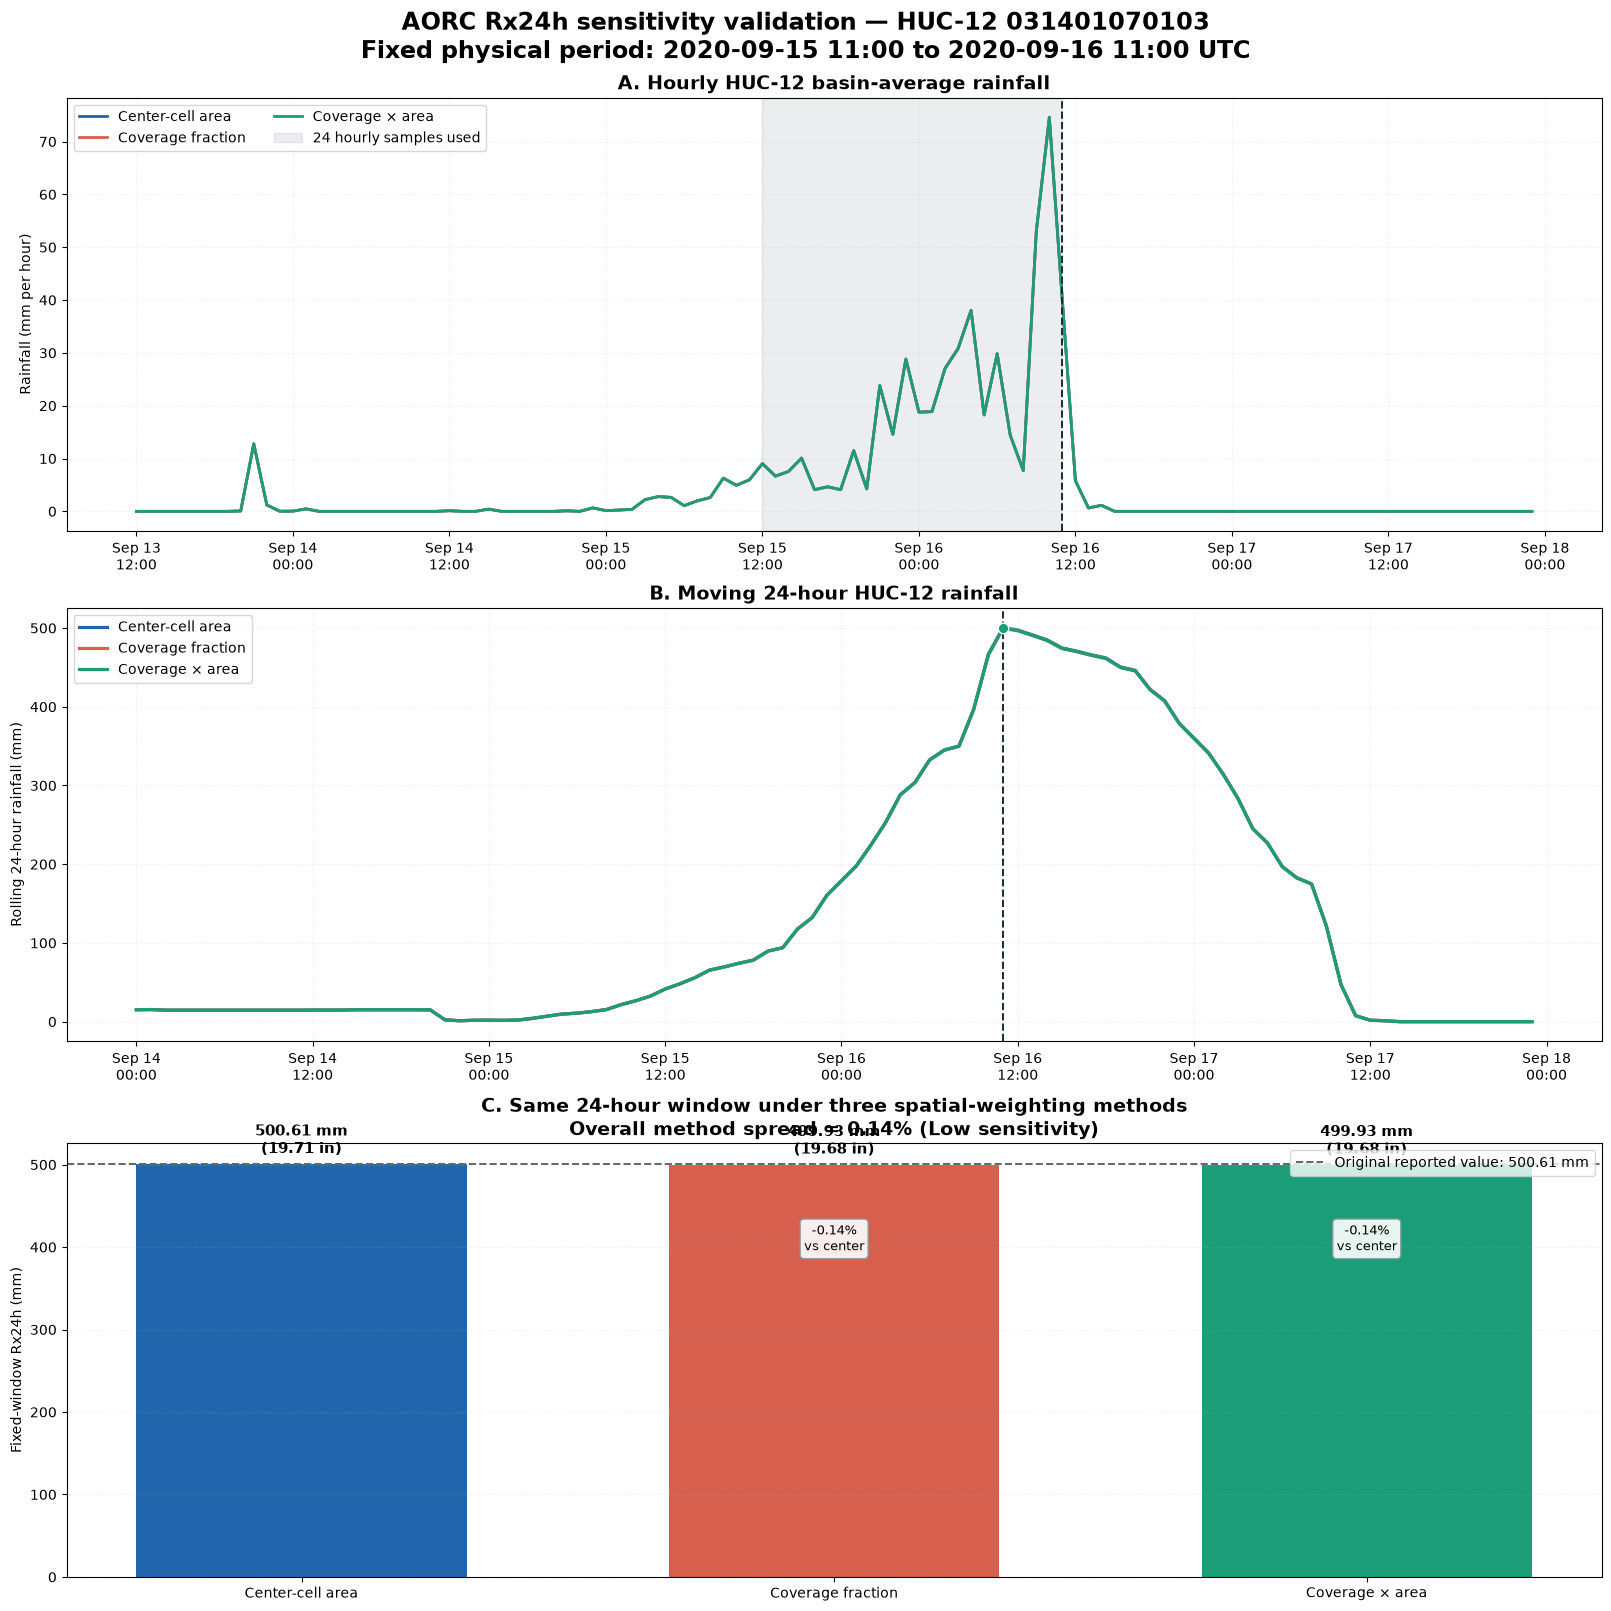

Saved: D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\04_figures\fig03_three_method_event_comparison.png


In [11]:
display_start = event_first_sample - pd.Timedelta(hours=DISPLAY_HOURS_BEFORE)
display_end = event_end + pd.Timedelta(hours=DISPLAY_HOURS_AFTER)

plot_hourly = hourly_df.loc[display_start:display_end]
plot_rolling = rolling24_df.loc[display_start:display_end]

figure, axes = plt.subplots(3, 1, figsize=(16, 16), constrained_layout=True)

# ------------------------------------------------------------
# Panel A — Hourly HUC-average rainfall
# ------------------------------------------------------------
axis = axes[0]
for method_key, method_info in METHODS.items():
    axis.plot(
        plot_hourly.index,
        plot_hourly[method_key],
        color=method_info["color"],
        linewidth=2.0,
        label=method_info["short_label"],
    )

axis.axvspan(
    event_first_sample,
    event_end,
    color="#8795a1",
    alpha=0.16,
    label="24 hourly samples used",
)
axis.axvline(event_end, color="#172a3a", linestyle="--", linewidth=1.4)
axis.set_title("A. Hourly HUC-12 basin-average rainfall", fontsize=14, fontweight="bold")
axis.set_ylabel("Rainfall (mm per hour)")
axis.grid(alpha=0.25, linestyle=":")
axis.legend(loc="upper left", ncol=2)
axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# ------------------------------------------------------------
# Panel B — Moving 24-hour totals
# ------------------------------------------------------------
axis = axes[1]
for method_key, method_info in METHODS.items():
    axis.plot(
        plot_rolling.index,
        plot_rolling[method_key],
        color=method_info["color"],
        linewidth=2.3,
        label=method_info["short_label"],
    )
    if event_end in plot_rolling.index:
        axis.scatter(
            event_end,
            plot_rolling.loc[event_end, method_key],
            color=method_info["color"],
            s=55,
            edgecolor="white",
            linewidth=0.8,
            zorder=5,
        )

axis.axvline(event_end, color="#172a3a", linestyle="--", linewidth=1.4)
axis.set_title("B. Moving 24-hour HUC-12 rainfall", fontsize=14, fontweight="bold")
axis.set_ylabel("Rolling 24-hour rainfall (mm)")
axis.grid(alpha=0.25, linestyle=":")
axis.legend(loc="upper left")
axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# ------------------------------------------------------------
# Panel C — Fixed-window totals
# ------------------------------------------------------------
axis = axes[2]
method_order = list(METHODS.keys())
bar_values = [float(fixed_totals[key]) for key in method_order]
bar_labels = [METHODS[key]["short_label"] for key in method_order]
bar_colors = [METHODS[key]["color"] for key in method_order]
positions = np.arange(len(method_order))

bars = axis.bar(positions, bar_values, color=bar_colors, width=0.62)
axis.axhline(
    ORIGINAL_REPORTED_RX24H_MM,
    color="#5c6770",
    linestyle="--",
    linewidth=1.4,
    label=f"Original reported value: {ORIGINAL_REPORTED_RX24H_MM:.2f} mm",
)

for bar, value, method_key in zip(bars, bar_values, method_order):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(bar_values) * 0.015,
        f"{value:.2f} mm\n({value / 25.4:.2f} in)",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
    )

    difference = pct_difference(value, center_total)
    if method_key != "center_area":
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value * 0.82,
            f"{difference:+.2f}%\nvs center",
            ha="center",
            va="center",
            fontsize=9.5,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "#8a99a6",
                "alpha": 0.9,
            },
        )

axis.set_xticks(positions)
axis.set_xticklabels(bar_labels)
axis.set_ylabel("Fixed-window Rx24h (mm)")
axis.set_title(
    "C. Same 24-hour window under three spatial-weighting methods\n"
    f"Overall method spread = {relative_spread_pct:.2f}% ({sensitivity_class})",
    fontsize=14,
    fontweight="bold",
)
axis.grid(axis="y", alpha=0.25, linestyle=":")
axis.legend(loc="upper right")

figure.suptitle(
    f"AORC Rx24h sensitivity validation — HUC-12 {TARGET_HUC12}\n"
    f"Fixed physical period: {physical_period_start:%Y-%m-%d %H:%M} to "
    f"{event_end:%Y-%m-%d %H:%M} UTC",
    fontsize=17,
    fontweight="bold",
)

figure_path = FIGURE_DIR / "fig03_three_method_event_comparison.png"
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")


## Cell 13 — Figure 4: compact publication-style validation dashboard

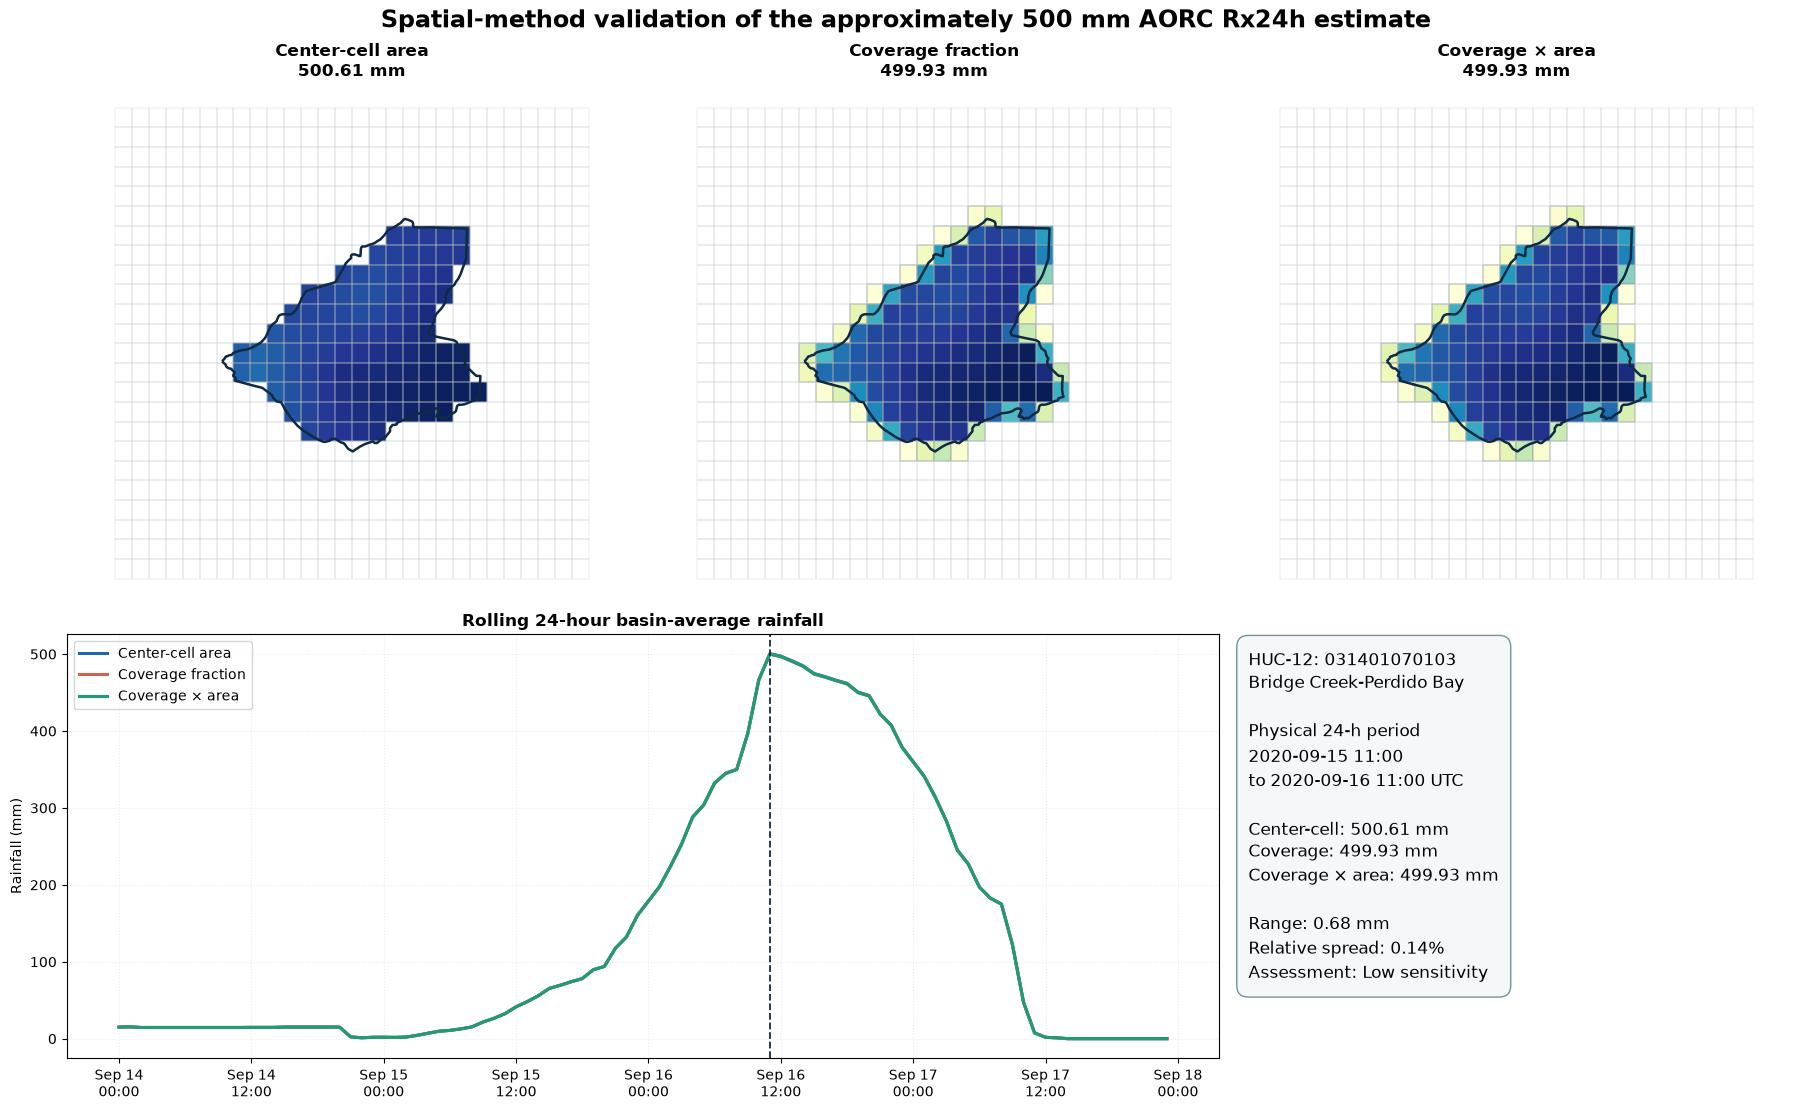

Saved: D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\04_figures\fig04_compact_validation_dashboard.png


In [12]:
figure = plt.figure(figsize=(18, 11), constrained_layout=True)
grid = figure.add_gridspec(2, 3, height_ratios=[1.1, 0.9])

# Top row: three spatial contribution maps.
for column_number, (method_key, method_info) in enumerate(METHODS.items()):
    axis = figure.add_subplot(grid[0, column_number])
    contribution_column = f"event_contribution_{method_key}_mm"

    cell_weights.boundary.plot(
        ax=axis,
        color="#c5cdd3",
        linewidth=0.28,
    )
    active = cell_weights[cell_weights[contribution_column] > 0].copy()
    active.plot(
        ax=axis,
        column=contribution_column,
        cmap="YlGnBu",
        vmin=0,
        vmax=common_contribution_max,
        edgecolor="#4b5d67",
        linewidth=0.3,
    )
    target_huc.boundary.plot(ax=axis, color="#102a43", linewidth=1.8)
    axis.set_title(
        f"{method_info['short_label']}\n{fixed_totals[method_key]:.2f} mm",
        fontweight="bold",
    )
    axis.set_axis_off()

# Bottom-left and bottom-centre: rolling time series.
axis = figure.add_subplot(grid[1, 0:2])
for method_key, method_info in METHODS.items():
    axis.plot(
        plot_rolling.index,
        plot_rolling[method_key],
        color=method_info["color"],
        linewidth=2.2,
        label=method_info["short_label"],
    )
axis.axvline(event_end, color="#172a3a", linestyle="--", linewidth=1.3)
axis.set_title("Rolling 24-hour basin-average rainfall", fontweight="bold")
axis.set_ylabel("Rainfall (mm)")
axis.grid(alpha=0.25, linestyle=":")
axis.legend(loc="upper left")
axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Bottom-right: concise statistical summary.
axis = figure.add_subplot(grid[1, 2])
axis.axis("off")

summary_text = (
    f"HUC-12: {TARGET_HUC12}\n"
    f"{target_name}\n\n"
    f"Physical 24-h period\n"
    f"{physical_period_start:%Y-%m-%d %H:%M}\n"
    f"to {event_end:%Y-%m-%d %H:%M} UTC\n\n"
    f"Center-cell: {fixed_totals['center_area']:.2f} mm\n"
    f"Coverage: {fixed_totals['coverage_fraction']:.2f} mm\n"
    f"Coverage × area: {fixed_totals['coverage_area']:.2f} mm\n\n"
    f"Range: {method_range_mm:.2f} mm\n"
    f"Relative spread: {relative_spread_pct:.2f}%\n"
    f"Assessment: {sensitivity_class}"
)

axis.text(
    0.03,
    0.97,
    summary_text,
    transform=axis.transAxes,
    va="top",
    ha="left",
    fontsize=12,
    linespacing=1.45,
    bbox={
        "boxstyle": "round,pad=0.7",
        "facecolor": "#f4f8fb",
        "edgecolor": "#78909c",
    },
)

figure.suptitle(
    "Spatial-method validation of the approximately 500 mm AORC Rx24h estimate",
    fontsize=17,
    fontweight="bold",
)

figure_path = FIGURE_DIR / "fig04_compact_validation_dashboard.png"
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")


## Cell 14 — Export tables, spatial data and reproducibility metadata

In [13]:
# ------------------------------------------------------------
# Export tabular results
# ------------------------------------------------------------
hourly_export = hourly_df.copy()
hourly_export.index.name = "time_utc"
hourly_export = hourly_export.join(
    rolling24_df.add_prefix("rolling24_")
)
hourly_export = hourly_export.join(
    coverage_df.add_prefix("coverage_")
)

hourly_csv = TABLE_DIR / f"huc12_{TARGET_HUC12}_three_method_hourly_series.csv"
summary_csv = TABLE_DIR / f"huc12_{TARGET_HUC12}_three_method_rx24h_summary.csv"
coverage_csv = TABLE_DIR / f"huc12_{TARGET_HUC12}_coverage_quality_control.csv"
validation_csv = TABLE_DIR / f"huc12_{TARGET_HUC12}_cell_contribution_validation.csv"

hourly_export.to_csv(hourly_csv)
summary_df.to_csv(summary_csv, index=False)
minimum_coverage_table.to_csv(coverage_csv)
contribution_validation.to_csv(validation_csv, index=False)

# ------------------------------------------------------------
# Export local AORC event grid and updated cell-weight layer
# ------------------------------------------------------------
precipitation.to_dataset(name="aorc_precip_mm").to_dataframe().reset_index().to_parquet(
    EVENT_GRID_PARQUET,
    index=False,
)

safe_delete(CELL_WEIGHTS_GPKG)
cell_weights.to_file(CELL_WEIGHTS_GPKG, layer="aorc_cells", driver="GPKG")

# ------------------------------------------------------------
# Reproducibility manifest
# ------------------------------------------------------------
manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_huc12": TARGET_HUC12,
    "target_name": target_name,
    "target_states": target_states,
    "wbd_reported_area_km2": target_wbd_area_km2,
    "event_year": EVENT_YEAR,
    "search_start_utc": str(search_start),
    "search_end_utc": str(search_end),
    "fixed_first_sample_utc": str(event_first_sample),
    "fixed_end_timestamp_utc": str(event_end),
    "physical_period_start_utc": str(physical_period_start),
    "aorc_bucket": AORC_BUCKET,
    "aorc_store": f"s3://{AORC_BUCKET}/{EVENT_YEAR}.zarr",
    "aorc_variable": AORC_VARIABLE,
    "wbd_layer_url": WBD_LAYER_URL,
    "minimum_spatial_coverage": MIN_SPATIAL_COVERAGE,
    "area_crs": AREA_CRS,
    "original_reported_rx24h_mm": ORIGINAL_REPORTED_RX24H_MM,
    "method_range_mm": float(method_range_mm),
    "relative_spread_pct": float(relative_spread_pct),
    "sensitivity_class": sensitivity_class,
    "methods": {
        key: {
            "label": value["label"],
            "weight_column": value["weight_column"],
            "fixed_window_rx24h_mm": float(fixed_totals[key]),
        }
        for key, value in METHODS.items()
    },
}

manifest_path = METADATA_DIR / "validation_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Outputs saved")
for output_path in [
    hourly_csv,
    summary_csv,
    coverage_csv,
    validation_csv,
    EVENT_GRID_PARQUET,
    CELL_WEIGHTS_GPKG,
    manifest_path,
]:
    print(f"  {output_path}")


Outputs saved
  D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\03_tables\huc12_031401070103_three_method_hourly_series.csv
  D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\03_tables\huc12_031401070103_three_method_rx24h_summary.csv
  D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\03_tables\huc12_031401070103_coverage_quality_control.csv
  D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\03_tables\huc12_031401070103_cell_contribution_validation.csv
  D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\02_event_data\aorc_event_grid_031401070103_2020.parquet
  D:\projstore\Ismail\Dr Koriche\Intense Rainfall and Flash Flooding\Data\AORC\AORC_HUC12_Three_Method_Validation\02_eve

## Cell 15 — Automatic interpretation of method sensitivity

In [14]:
center_row = summary_df.loc[summary_df["method_key"] == "center_area"].iloc[0]
coverage_row = summary_df.loc[summary_df["method_key"] == "coverage_fraction"].iloc[0]
hybrid_row = summary_df.loc[summary_df["method_key"] == "coverage_area"].iloc[0]

print("=" * 84)
print("AORC HUC-12 RX24H SPATIAL-METHOD VALIDATION")
print("=" * 84)
print(f"HUC-12: {TARGET_HUC12} — {target_name}")
print(f"States: {target_states}")
print(f"Physical rainfall period: {physical_period_start} to {event_end} UTC")
print()
print(f"Method 1 — Center-cell area:        {center_row['fixed_window_rx24h_mm']:.2f} mm")
print(f"Method 2 — Coverage fraction:       {coverage_row['fixed_window_rx24h_mm']:.2f} mm")
print(f"Method 3 — Coverage × physical cell area:      {hybrid_row['fixed_window_rx24h_mm']:.2f} mm")
print()
print(f"Difference, coverage vs center: {coverage_row['pct_difference_vs_center']:+.2f}%")
print(f"Difference, hybrid vs center:   {hybrid_row['pct_difference_vs_center']:+.2f}%")
print(f"Overall method range:           {method_range_mm:.2f} mm")
print(f"Relative method spread:         {relative_spread_pct:.2f}%")
print(f"Sensitivity assessment:         {sensitivity_class}")
print()

if relative_spread_pct < 5:
    print(
        "Interpretation: The high Rx24h estimate is robust to the three spatial-weighting "
        "methods. Boundary-cell treatment changes the exact value only slightly."
    )
elif relative_spread_pct < 10:
    print(
        "Interpretation: The estimate shows moderate sensitivity to boundary-cell treatment. "
        "Use the exact overlap-area result as the preferred value and report the method range."
    )
else:
    print(
        "Interpretation: The estimate is strongly sensitive to spatial aggregation. "
        "The center-cell estimate should not be used alone; retain the exact overlap-area "
        "result and investigate the highest-contributing boundary cells."
    )

print()
print(
    "Note: Method 2 follows the CIROH weighting concept, while Method 3 adds physical "
    "cell area and is the most defensible choice for this geographic latitude–longitude grid."
)

# Close the source dataset after all analysis is complete.
aorc_source_dataset.close()


AORC HUC-12 RX24H SPATIAL-METHOD VALIDATION
HUC-12: 031401070103 — Bridge Creek-Perdido Bay
States: AL,FL
Physical rainfall period: 2020-09-15 11:00:00 to 2020-09-16 11:00:00 UTC

Method 1 — Center-cell area:        500.61 mm
Method 2 — Coverage fraction:       499.93 mm
Method 3 — Coverage × physical cell area:      499.93 mm

Difference, coverage vs center: -0.14%
Difference, hybrid vs center:   -0.14%
Overall method range:           0.68 mm
Relative method spread:         0.14%
Sensitivity assessment:         Low sensitivity

Interpretation: The high Rx24h estimate is robust to the three spatial-weighting methods. Boundary-cell treatment changes the exact value only slightly.

Note: Method 2 follows the CIROH weighting concept, while Method 3 adds physical cell area and is the most defensible choice for this geographic latitude–longitude grid.


## Expected deliverables

After all cells run successfully, the project folder contains:

- the target online WBD HUC-12 boundary;
- the online AORC storm-window grid subset;
- a GeoPackage of AORC grid cells with all three weights and event contributions;
- a CSV comparison table with values and percentage differences;
- hourly and rolling 24-hour time series;
- four 300-dpi figures, including two three-panel maps and a three-panel event comparison;
- a JSON reproducibility manifest.

### Interpretation rule used by the notebook

- **Below 5% relative spread:** low sensitivity;
- **5% to below 10%:** moderate sensitivity;
- **10% or more:** high sensitivity.

Method 3 — exact coverage fraction × physical cell area — is treated as the preferred final basin-average estimate because it accounts for both partial boundary cells and the physical area of each AORC grid cell.
